# CopulaAlpha LAB - MVP Research Notebook

Questo notebook sviluppa il primo MVP del progetto **Copula-Based Relative-Value Alpha Engine**.

L'obiettivo e costruire una pipeline end-to-end, semplice ma completa, per testare se copule rolling **Gaussian**, **Student-t**, **Clayton** e **mixture** possono generare segnali relative-value tra ETF liquidi.

Workflow MVP:

1. scaricare adjusted close ETF;
2. calcolare log returns giornalieri;
3. selezionare coppie top-correlated usando solo il periodo train;
4. stimare una copula rolling per ogni coppia;
5. trasformare la probabilita condizionale in segnale rich/cheap;
6. costruire un portafoglio pair-trading dollar-neutral;
7. backtestare con shift di un giorno e transaction costs;
8. calcolare metriche di performance e IC.

Nota importante: in questo MVP non assumiamo che la copula migliori la strategia. La testiamo come feature di alpha research.

## Domanda di ricerca

La domanda principale e:

> Le copule rolling Gaussian, Student-t, Clayton e mixture riescono a estrarre segnali relative-value stabili tra ETF correlati?

Il criterio sperimentale e out-of-sample:

- il pair universe viene selezionato sul train;
- i parametri rolling usano solo dati passati;
- le posizioni sono shiftate di un giorno prima del PnL;
- i risultati vengono separati in train, validation e test.

Split usato nel notebook:

| Periodo | Date |
|---|---|
| Train | 2015-01-01 / 2020-12-31 |
| Validation | 2021-01-01 / 2022-12-31 |
| Test | 2023-01-01 / latest available date |

## Matematica del segnale

I prezzi adjusted close vengono trasformati in log returns:

$$
r_{i,t} = \log\left(\frac{P_{i,t}}{P_{i,t-1}}\right)
$$

Per ogni coppia di asset, i returns nella finestra rolling di lunghezza $W$ vengono trasformati in pseudo-osservazioni empiriche:

$$
u_{i,t} = \frac{\operatorname{rank}(r_{i,t})}{W+1}
$$

### Gaussian copula

La Gaussian copula bivariata e:

$$
C_{\rho}(u,v) = \Phi_{\rho}\left(\Phi^{-1}(u), \Phi^{-1}(v)\right)
$$

dove $\Phi^{-1}$ e la inverse standard normal CDF, $\Phi_{\rho}$ e la bivariate normal CDF, e $\rho$ e il parametro di dipendenza.

Definiamo:

$$
z_i = \Phi^{-1}(u_i), \qquad z_j = \Phi^{-1}(u_j)
$$

Per una Gaussian copula:

$$
z_i \mid z_j \sim \mathcal{N}\left(\rho z_j, 1 - \rho^2\right)
$$

La probabilita condizionale osservata e:

$$
p_{i \mid j,t} = \Phi\left(\frac{z_{i,t} - \rho_t z_{j,t}}{\sqrt{1 - \rho_t^2}}\right)
$$

Il mispricing score e:

$$
s_{i \mid j,t} = p_{i \mid j,t} - 0.5
$$

Interpretazione:

- $s_{i \mid j,t} > 0$: asset $i$ appare rich rispetto a $j$, quindi short $i$, long $j$;
- $s_{i \mid j,t} < 0$: asset $i$ appare cheap rispetto a $j$, quindi long $i$, short $j$.

Nel codice usiamo una soglia su $|s|$. Per esempio, una soglia score pari a 0.25 equivale a una conditional probability sopra 0.75 o sotto 0.25.

### Student-t copula

La Student-t copula sostituisce la normale multivariata con una t multivariata. Questo permette di catturare co-movimenti estremi simmetrici, utili quando due asset diventano piu dipendenti nelle code.

$$
C_{\rho,\nu}^{t}(u,v) = t_{\rho,\nu}\left(t_{\nu}^{-1}(u), t_{\nu}^{-1}(v)\right)
$$

dove $t_{\nu}^{-1}$ e la inverse CDF della t univariata con $\nu$ gradi di liberta, mentre $t_{\rho,\nu}$ e la CDF t bivariata con correlazione $\rho$.

Definiamo:

$$
x_i = t_{\nu}^{-1}(u_i), \qquad x_j = t_{\nu}^{-1}(u_j)
$$

Per una t bivariata:

$$
x_i \mid x_j \sim t_{\nu+1}\left(\rho x_j, \sqrt{\frac{(\nu + x_j^2)(1 - \rho^2)}{\nu + 1}}\right)
$$

La probabilita condizionale usata nel segnale e:

$$
p_{i \mid j,t}^{t} = t_{\nu+1}\left(\frac{x_{i,t} - \rho_t x_{j,t}}{\sqrt{\frac{(\nu + x_{j,t}^{2})(1 - \rho_t^2)}{\nu + 1}}}\right)
$$

Nel MVP $\nu$ e fissato da configurazione. La stima rolling di $\nu$ e lasciata come estensione, perche puo diventare instabile su finestre corte.

### Clayton copula

La Clayton copula e una copula Archimedean con lower-tail dependence. E utile quando la dipendenza aumenta soprattutto nei movimenti negativi o risk-off.

$$
C_{\theta}^{Clayton}(u,v) = \left(u^{-\theta} + v^{-\theta} - 1\right)^{-1/\theta}, \qquad \theta > 0
$$

La relazione tra Kendall tau e il parametro Clayton e:

$$
\tau = \frac{\theta}{\theta + 2}
$$

quindi:

$$
\theta = \frac{2\tau}{1 - \tau}
$$

La conditional CDF di $U_i$ dato $U_j=v$ e la derivata parziale della copula rispetto a $v$:

$$
p_{i \mid j,t}^{Clayton} = \frac{\partial C_{\theta}(u_i,u_j)}{\partial u_j}
$$

$$
p_{i \mid j,t}^{Clayton} = u_{j,t}^{-\theta-1}\left(u_{i,t}^{-\theta} + u_{j,t}^{-\theta} - 1\right)^{-1/\theta - 1}
$$

La Clayton copula classica supporta dipendenza positiva. Se la Kendall tau rolling e non positiva, il codice usa il limite di indipendenza:

$$
p_{i \mid j,t}^{independent} = u_{i,t}
$$

### Mixture copula

La mixture copula combina piu famiglie di copule in un unico modello pesato. Nel notebook usiamo una mixture di Gaussian, Student-t e Clayton:

$$
C_{mix}(u,v) = w_G C_G(u,v) + w_T C_T(u,v) + w_C C_C(u,v)
$$

con vincoli:

$$
w_G \ge 0, \qquad w_T \ge 0, \qquad w_C \ge 0
$$

$$
w_G + w_T + w_C = 1
$$

La probabilita condizionale della mixture e una combinazione pesata delle probabilita condizionali dei componenti:

$$
p_{i \mid j,t}^{mix} = w_G p_{i \mid j,t}^{G} + w_T p_{i \mid j,t}^{T} + w_C p_{i \mid j,t}^{C}
$$

Il mispricing score resta:

$$
s_{i \mid j,t}^{mix} = p_{i \mid j,t}^{mix} - 0.5
$$

Nel MVP i pesi sono configurabili ma fissi. La stima rolling dei pesi via conditional likelihood e una naturale estensione successiva.

In [12]:
from __future__ import annotations

import math
import warnings
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import kendalltau, norm, rankdata, spearmanr, t as student_t

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 140)

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_RAW_DIR = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
RESULTS_DIR = PROJECT_ROOT / "results"
PLOTS_DIR = RESULTS_DIR / "plots"

for directory in [DATA_RAW_DIR, DATA_PROCESSED_DIR, RESULTS_DIR, PLOTS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

ETF_UNIVERSE = [
    "SPY", "QQQ", "IWM", "DIA",
    "EFA", "EEM", "VGK", "EWJ",
    "TLT", "IEF", "SHY", "LQD", "HYG",
    "GLD", "SLV", "USO", "DBA",
    "XLK", "XLF", "XLE", "XLY", "XLI",
    "XLP", "XLU", "XLV", "XLB", "XLRE",
    "SMH", "IBB", "KRE", "XRT", "ITA",
    "VNQ", "IYR", "DBC", "UUP", "FXE",
    "FXY", "FXB", "EWT", "EWG", "EWU",
]

@dataclass(frozen=True)
class MVPConfig:
    start_date: str = "2015-01-01"
    end_date: str | None = None
    train_end: str = "2020-12-31"
    validation_start: str = "2021-01-01"
    validation_end: str = "2022-12-31"
    test_start: str = "2023-01-01"
    rolling_window: int = 252
    copula_model: str = "mixture"
    student_t_df: int = 6
    mixture_weights: tuple[float, float, float] = (1.0 / 3.0, 1.0 / 3.0, 1.0 / 3.0)
    peers_per_asset: int = 3
    max_candidate_pairs: int = 20
    top_n_pairs: int = 10
    entry_score: float = 0.35
    rebalance_every_n_days: int = 5
    max_daily_turnover: float | None = 0.35
    cost_bps: float = 5.0
    min_history_fraction: float = 0.85

CONFIG = MVPConfig()
CONFIG

MVPConfig(start_date='2015-01-01', end_date=None, train_end='2020-12-31', validation_start='2021-01-01', validation_end='2022-12-31', test_start='2023-01-01', rolling_window=252, copula_model='mixture', student_t_df=6, mixture_weights=(0.3333333333333333, 0.3333333333333333, 0.3333333333333333), peers_per_asset=3, max_candidate_pairs=20, top_n_pairs=10, entry_score=0.35, rebalance_every_n_days=5, max_daily_turnover=0.35, cost_bps=5.0, min_history_fraction=0.85)

## Data pipeline

La funzione sotto scarica adjusted close via `yfinance`, salva una cache locale e calcola log returns. Se `yfinance` non e installato, installarlo nell'ambiente del notebook:

```bash
pip install yfinance
```

La pulizia MVP e intenzionalmente semplice: rimuove asset con storia insufficiente, forward-fill limitato dal dataset scaricato, poi tiene solo date comuni agli asset rimasti.

In [13]:
def download_adjusted_prices(tickers: list[str], start: str, end: str | None = None) -> pd.DataFrame:
    try:
        import yfinance as yf
    except ImportError as exc:
        raise ImportError("yfinance non e installato. Esegui: pip install yfinance") from exc

    raw = yf.download(
        tickers,
        start=start,
        end=end,
        auto_adjust=True,
        progress=False,
        group_by="column",
        threads=True,
    )

    if isinstance(raw.columns, pd.MultiIndex):
        if "Close" not in raw.columns.get_level_values(0):
            raise ValueError("Colonna Close non trovata nel download yfinance.")
        prices = raw["Close"].copy()
    else:
        prices = raw[["Close"]].copy()
        prices.columns = tickers[:1]

    prices = prices.sort_index()
    prices.index = pd.to_datetime(prices.index)
    prices = prices.apply(pd.to_numeric, errors="coerce")
    prices = prices.dropna(axis=1, how="all")

    min_obs = int(len(prices) * CONFIG.min_history_fraction)
    prices = prices.dropna(axis=1, thresh=min_obs)
    prices = prices.ffill().dropna(axis=0, how="any")
    prices = prices.loc[:, sorted(prices.columns)]
    return prices


def load_or_download_prices(refresh: bool = False) -> pd.DataFrame:
    prices_path = DATA_PROCESSED_DIR / "prices.csv"
    if prices_path.exists() and not refresh:
        prices = pd.read_csv(prices_path, index_col=0, parse_dates=True)
        return prices.sort_index()

    prices = download_adjusted_prices(ETF_UNIVERSE, CONFIG.start_date, CONFIG.end_date)
    prices.to_csv(prices_path)
    return prices


def compute_log_returns(prices: pd.DataFrame) -> pd.DataFrame:
    returns = np.log(prices / prices.shift(1)).dropna(how="any")
    returns.to_csv(DATA_PROCESSED_DIR / "returns.csv")
    return returns

## Pair selection

Per evitare look-ahead bias, le coppie candidate vengono selezionate solo sui returns del periodo train.

Regola MVP:

$$
\mathcal{P} = \{(i,j): j \in \operatorname{TopKCorr}(i)\}
$$

dove la correlazione e stimata sui daily log returns nel train.

In [14]:
def select_candidate_pairs(
    returns: pd.DataFrame,
    train_end: str,
    top_k: int,
    max_pairs: int,
) -> pd.DataFrame:
    train_returns = returns.loc[:train_end].copy()
    corr = train_returns.corr()

    pair_records: list[dict[str, object]] = []
    seen: set[tuple[str, str]] = set()

    for asset in corr.columns:
        peers = corr[asset].drop(labels=[asset]).sort_values(ascending=False).head(top_k)
        for peer, rho in peers.items():
            pair = tuple(sorted((asset, peer)))
            if pair in seen:
                continue
            seen.add(pair)
            pair_records.append({"asset_i": pair[0], "asset_j": pair[1], "corr_train": float(corr.loc[pair[0], pair[1]])})

    pairs = pd.DataFrame(pair_records)
    pairs = pairs.sort_values("corr_train", ascending=False).head(max_pairs).reset_index(drop=True)
    pairs.to_csv(DATA_PROCESSED_DIR / "candidate_pairs.csv", index=False)
    return pairs


def describe_pairs(pairs: pd.DataFrame) -> pd.DataFrame:
    return pairs.assign(abs_corr=lambda x: x["corr_train"].abs()).describe(include="all")

## Rolling copula signals

Per ogni data $t$, stimiamo $\rho_t$ sulla finestra $[t-W, t-1]$, poi valutiamo il return osservato in $t$. Questo permette di generare il segnale a fine giornata $t$ senza usare dati futuri. Il PnL usa posizioni shiftate di un giorno.

La stima di $\rho_t$ per Gaussian e Student-t avviene sui transformed scores dei ranks empirici della finestra rolling. Per Clayton stimiamo $\theta_t$ dalla Kendall tau rolling. Per la mixture combiniamo le tre probabilita condizionali con pesi configurabili.

In [15]:
SUPPORTED_COPULA_MODELS = {"gaussian", "student_t", "clayton", "mixture", "mixed"}
COPULA_MODEL_ALIASES = {"mixed": "mixture"}


def canonical_copula_model(copula_model: str) -> str:
    copula_model = copula_model.strip().lower()
    return COPULA_MODEL_ALIASES.get(copula_model, copula_model)


def normalize_mixture_weights(weights: tuple[float, float, float]) -> tuple[float, float, float]:
    weight_array = np.asarray(weights, dtype=float)
    if weight_array.shape != (3,):
        raise ValueError("mixture_weights must contain exactly three values: Gaussian, Student-t, Clayton.")
    if np.any(weight_array < 0):
        raise ValueError("mixture_weights must be non-negative.")
    total_weight = weight_array.sum()
    if total_weight <= 0:
        raise ValueError("At least one mixture weight must be positive.")
    normalized = weight_array / total_weight
    return float(normalized[0]), float(normalized[1]), float(normalized[2])


def empirical_u_history(values: np.ndarray) -> np.ndarray:
    ranks = rankdata(values, method="average")
    return ranks / (len(values) + 1.0)


def empirical_u_current(history: np.ndarray, current_value: float) -> float:
    # Smoothed empirical CDF to avoid exact 0 or 1.
    return (np.sum(history <= current_value) + 1.0) / (len(history) + 2.0)


def estimate_gaussian_copula_rho(x_hist: np.ndarray, y_hist: np.ndarray) -> float:
    ux = empirical_u_history(x_hist)
    uy = empirical_u_history(y_hist)
    zx = norm.ppf(ux)
    zy = norm.ppf(uy)
    rho = np.corrcoef(zx, zy)[0, 1]
    if np.isnan(rho):
        return 0.0
    return float(np.clip(rho, -0.95, 0.95))


def estimate_student_t_copula_rho(x_hist: np.ndarray, y_hist: np.ndarray, df: int) -> float:
    ux = empirical_u_history(x_hist)
    uy = empirical_u_history(y_hist)
    tx = student_t.ppf(ux, df=df)
    ty = student_t.ppf(uy, df=df)
    rho = np.corrcoef(tx, ty)[0, 1]
    if np.isnan(rho):
        return 0.0
    return float(np.clip(rho, -0.95, 0.95))


def estimate_clayton_theta(x_hist: np.ndarray, y_hist: np.ndarray) -> tuple[float, float]:
    tau_result = kendalltau(x_hist, y_hist, nan_policy="omit")
    tau = float(tau_result.statistic if hasattr(tau_result, "statistic") else tau_result[0])
    if np.isnan(tau) or tau <= 0:
        return 0.0, tau
    tau = float(np.clip(tau, 1e-6, 0.95))
    theta = 2.0 * tau / (1.0 - tau)
    return float(np.clip(theta, 1e-6, 30.0)), tau


def gaussian_conditional_probability(u_i: float, u_j: float, rho: float) -> float:
    z_i = norm.ppf(np.clip(u_i, 1e-6, 1 - 1e-6))
    z_j = norm.ppf(np.clip(u_j, 1e-6, 1 - 1e-6))
    denominator = math.sqrt(max(1e-8, 1.0 - rho**2))
    return float(norm.cdf((z_i - rho * z_j) / denominator))


def student_t_conditional_probability(u_i: float, u_j: float, rho: float, df: int) -> float:
    x_i = student_t.ppf(np.clip(u_i, 1e-6, 1 - 1e-6), df=df)
    x_j = student_t.ppf(np.clip(u_j, 1e-6, 1 - 1e-6), df=df)
    scale = math.sqrt(max(1e-8, ((df + x_j**2) * (1.0 - rho**2)) / (df + 1.0)))
    return float(student_t.cdf((x_i - rho * x_j) / scale, df=df + 1))


def clayton_conditional_probability(u_i: float, u_j: float, theta: float) -> float:
    u_i = float(np.clip(u_i, 1e-6, 1 - 1e-6))
    u_j = float(np.clip(u_j, 1e-6, 1 - 1e-6))
    if theta <= 1e-6:
        return u_i
    base = max(u_i ** (-theta) + u_j ** (-theta) - 1.0, 1e-12)
    conditional_prob = u_j ** (-theta - 1.0) * base ** (-1.0 / theta - 1.0)
    return float(np.clip(conditional_prob, 0.0, 1.0))


def copula_conditional_probability(
    copula_model: str,
    x_hist: np.ndarray,
    y_hist: np.ndarray,
    u_i: float,
    u_j: float,
    student_t_df: int,
    mixture_weights: tuple[float, float, float],
) -> tuple[float, dict[str, float]]:
    copula_model = canonical_copula_model(copula_model)
    if copula_model == "gaussian":
        rho = estimate_gaussian_copula_rho(x_hist, y_hist)
        conditional_prob = gaussian_conditional_probability(u_i, u_j, rho)
        return conditional_prob, {"rho": rho, "theta": np.nan, "kendall_tau": np.nan, "nu": np.nan}

    if copula_model == "student_t":
        rho = estimate_student_t_copula_rho(x_hist, y_hist, df=student_t_df)
        conditional_prob = student_t_conditional_probability(u_i, u_j, rho, df=student_t_df)
        return conditional_prob, {"rho": rho, "theta": np.nan, "kendall_tau": np.nan, "nu": float(student_t_df)}

    if copula_model == "clayton":
        theta, tau = estimate_clayton_theta(x_hist, y_hist)
        conditional_prob = clayton_conditional_probability(u_i, u_j, theta)
        return conditional_prob, {"rho": np.nan, "theta": theta, "kendall_tau": tau, "nu": np.nan}

    if copula_model == "mixture":
        weight_gaussian, weight_student_t, weight_clayton = normalize_mixture_weights(mixture_weights)

        gaussian_rho = estimate_gaussian_copula_rho(x_hist, y_hist)
        student_t_rho = estimate_student_t_copula_rho(x_hist, y_hist, df=student_t_df)
        clayton_theta, clayton_tau = estimate_clayton_theta(x_hist, y_hist)

        conditional_prob_gaussian = gaussian_conditional_probability(u_i, u_j, gaussian_rho)
        conditional_prob_student_t = student_t_conditional_probability(u_i, u_j, student_t_rho, df=student_t_df)
        conditional_prob_clayton = clayton_conditional_probability(u_i, u_j, clayton_theta)
        conditional_prob = (
            weight_gaussian * conditional_prob_gaussian
            + weight_student_t * conditional_prob_student_t
            + weight_clayton * conditional_prob_clayton
        )

        return float(conditional_prob), {
            "rho": gaussian_rho,
            "student_t_rho": student_t_rho,
            "theta": clayton_theta,
            "kendall_tau": clayton_tau,
            "nu": float(student_t_df),
            "weight_gaussian": weight_gaussian,
            "weight_student_t": weight_student_t,
            "weight_clayton": weight_clayton,
            "conditional_prob_gaussian": conditional_prob_gaussian,
            "conditional_prob_student_t": conditional_prob_student_t,
            "conditional_prob_clayton": conditional_prob_clayton,
        }

    raise ValueError(f"Unsupported copula_model={copula_model!r}. Use one of {sorted(SUPPORTED_COPULA_MODELS)}.")


def rolling_copula_pair_signals(
    returns: pd.DataFrame,
    pairs: pd.DataFrame,
    window: int,
    copula_model: str = "gaussian",
    student_t_df: int = 6,
    mixture_weights: tuple[float, float, float] = (1.0 / 3.0, 1.0 / 3.0, 1.0 / 3.0),
    output_path: Path | None = RESULTS_DIR / "pair_signals.csv",
) -> pd.DataFrame:
    copula_model = canonical_copula_model(copula_model)
    if copula_model not in SUPPORTED_COPULA_MODELS:
        raise ValueError(f"Unsupported copula_model={copula_model!r}. Use one of {sorted(SUPPORTED_COPULA_MODELS)}.")
    if student_t_df <= 2:
        raise ValueError("student_t_df must be greater than 2.")

    signal_records: list[dict[str, object]] = []

    for row in pairs.itertuples(index=False):
        asset_i = row.asset_i
        asset_j = row.asset_j
        pair_returns = returns[[asset_i, asset_j]].dropna()
        values_i = pair_returns[asset_i].to_numpy()
        values_j = pair_returns[asset_j].to_numpy()
        dates = pair_returns.index

        for pos in range(window, len(pair_returns)):
            x_hist = values_i[pos - window:pos]
            y_hist = values_j[pos - window:pos]
            x_now = values_i[pos]
            y_now = values_j[pos]

            u_i = empirical_u_current(x_hist, x_now)
            u_j = empirical_u_current(y_hist, y_now)
            conditional_prob, params = copula_conditional_probability(
                copula_model=copula_model,
                x_hist=x_hist,
                y_hist=y_hist,
                u_i=u_i,
                u_j=u_j,
                student_t_df=student_t_df,
                mixture_weights=mixture_weights,
            )
            mispricing_score = conditional_prob - 0.5

            signal_records.append(
                {
                    "date": dates[pos],
                    "asset_i": asset_i,
                    "asset_j": asset_j,
                    "copula_model": copula_model,
                    **params,
                    "u_i": u_i,
                    "u_j": u_j,
                    "conditional_prob": conditional_prob,
                    "mispricing_score": mispricing_score,
                }
            )

    signals = pd.DataFrame(signal_records)
    if not signals.empty:
        signals = signals.sort_values(["date", "asset_i", "asset_j"]).reset_index(drop=True)
    if output_path is not None:
        signals.to_csv(output_path, index=False)
    return signals


def rolling_gaussian_pair_signals(
    returns: pd.DataFrame,
    pairs: pd.DataFrame,
    window: int,
    output_path: Path | None = RESULTS_DIR / "pair_signals.csv",
) -> pd.DataFrame:
    return rolling_copula_pair_signals(
        returns=returns,
        pairs=pairs,
        window=window,
        copula_model="gaussian",
        student_t_df=CONFIG.student_t_df,
        mixture_weights=CONFIG.mixture_weights,
        output_path=output_path,
    )

## Portfolio construction e backtest

Nei giorni di rebalance selezioniamo i segnali piu forti per valore assoluto, costruiamo pair trades dollar-neutral e normalizziamo il gross exposure a 1. Tra un rebalance e il successivo manteniamo le posizioni, cosi il portafoglio non viene ricostruito ogni giorno.

Per controllare il turnover usiamo tre leve:

- `entry_score`: entra solo su segnali abbastanza estremi;
- `top_n_pairs`: limita il numero massimo di coppie tradate;
- `max_daily_turnover`: scala il trade giornaliero se il cambio posizione e troppo grande.

La regola di PnL evita look-ahead bias:

$$
\operatorname{PnL}_{t} = \sum_i w_{i,t-1} r_{i,t}
$$

I costi sono proporzionali al turnover:

$$
\operatorname{Cost}_{t} = \operatorname{Turnover}_{t} \times \frac{\operatorname{cost\_bps}}{10000}
$$

$$
R^{net}_{t} = R^{gross}_{t} - \operatorname{Cost}_{t}
$$

In [16]:
def build_positions_from_pair_signals(
    signals: pd.DataFrame,
    returns: pd.DataFrame,
    top_n_pairs: int,
    entry_score: float,
    rebalance_every_n_days: int = 1,
    max_daily_turnover: float | None = None,
    output_path: Path | None = RESULTS_DIR / "daily_positions.csv",
) -> pd.DataFrame:
    positions = pd.DataFrame(0.0, index=returns.index, columns=returns.columns)
    if signals.empty:
        return positions

    if rebalance_every_n_days < 1:
        raise ValueError("rebalance_every_n_days must be at least 1.")
    if max_daily_turnover is not None and max_daily_turnover <= 0:
        raise ValueError("max_daily_turnover must be positive or None.")

    signals_by_date = {pd.Timestamp(date): group for date, group in signals.groupby("date")}

    def target_position_for_day(day_signals: pd.DataFrame) -> pd.Series:
        target = pd.Series(0.0, index=returns.columns)
        active = day_signals.loc[day_signals["mispricing_score"].abs() >= entry_score].copy()
        if active.empty:
            return target

        active = active.assign(abs_score=active["mispricing_score"].abs())
        active = active.sort_values("abs_score", ascending=False).head(top_n_pairs)

        for signal in active.itertuples(index=False):
            leg_weight = 0.5
            if signal.mispricing_score > 0:
                # Asset i rich: short i, long j.
                target.loc[signal.asset_i] -= leg_weight
                target.loc[signal.asset_j] += leg_weight
            else:
                # Asset i cheap: long i, short j.
                target.loc[signal.asset_i] += leg_weight
                target.loc[signal.asset_j] -= leg_weight

        gross = target.abs().sum()
        if gross > 0:
            target = target / gross
        return target

    previous_position = pd.Series(0.0, index=returns.columns)
    for idx, date in enumerate(returns.index):
        is_rebalance_day = idx % rebalance_every_n_days == 0
        if is_rebalance_day and date in signals_by_date:
            target_position = target_position_for_day(signals_by_date[date])
        else:
            target_position = previous_position.copy()

        trade = target_position - previous_position
        day_turnover = trade.abs().sum()
        if max_daily_turnover is not None and day_turnover > max_daily_turnover:
            trade = trade * (max_daily_turnover / day_turnover)
            target_position = previous_position + trade

        positions.loc[date] = target_position
        previous_position = target_position

    if output_path is not None:
        positions.to_csv(output_path)
    return positions


def run_backtest(
    positions: pd.DataFrame,
    returns: pd.DataFrame,
    cost_bps: float,
    output_path: Path | None = RESULTS_DIR / "backtest.csv",
) -> pd.DataFrame:
    positions = positions.reindex(returns.index).fillna(0.0)
    positions_for_pnl = positions.shift(1).fillna(0.0)

    gross_return = (positions_for_pnl * returns).sum(axis=1)
    turnover = positions.diff().abs().sum(axis=1).fillna(positions.abs().sum(axis=1))
    transaction_cost = turnover * cost_bps / 10000.0
    net_return = gross_return - transaction_cost

    backtest = pd.DataFrame(
        {
            "gross_return": gross_return,
            "turnover": turnover,
            "transaction_cost": transaction_cost,
            "net_return": net_return,
            "gross_exposure": positions.abs().sum(axis=1),
            "net_exposure": positions.sum(axis=1),
        }
    )
    backtest["gross_equity"] = (1.0 + backtest["gross_return"]).cumprod()
    backtest["net_equity"] = (1.0 + backtest["net_return"]).cumprod()
    if output_path is not None:
        backtest.to_csv(output_path)
    return backtest

## Metrics e IC

Oltre alle metriche di performance, misuriamo se il segnale ha contenuto predittivo cross-sectionally.

Per ogni coppia, se $s_{i \mid j,t}$ e positivo, il trade atteso e short $i$, long $j$. Quindi il target a un giorno e:

$$
y_{i,j,t+1} = -\left(r_{i,t+1} - r_{j,t+1}\right)
$$

L'information coefficient giornaliero e:

$$
IC_t = \operatorname{corr}\left(s_{i \mid j,t}, y_{i,j,t+1}\right)
$$

Il rank IC usa Spearman correlation al posto di Pearson.

In [17]:
def max_drawdown(equity: pd.Series) -> float:
    running_max = equity.cummax()
    drawdown = equity / running_max - 1.0
    return float(drawdown.min())


def performance_stats(
    backtest: pd.DataFrame,
    returns: pd.DataFrame,
    strategy_col: str = "net_return",
) -> dict[str, float]:
    strategy_returns = backtest[strategy_col].dropna()
    if strategy_returns.empty:
        return {}

    n_days = len(strategy_returns)
    equity = (1.0 + strategy_returns).cumprod()
    ann_return = float(equity.iloc[-1] ** (252.0 / n_days) - 1.0)
    ann_vol = float(strategy_returns.std(ddof=1) * math.sqrt(252.0))
    sharpe = float(strategy_returns.mean() / strategy_returns.std(ddof=1) * math.sqrt(252.0)) if strategy_returns.std(ddof=1) > 0 else np.nan

    downside = strategy_returns[strategy_returns < 0]
    sortino = float(strategy_returns.mean() / downside.std(ddof=1) * math.sqrt(252.0)) if len(downside) > 1 and downside.std(ddof=1) > 0 else np.nan
    mdd = max_drawdown(equity)
    calmar = float(ann_return / abs(mdd)) if mdd < 0 else np.nan

    beta = np.nan
    if "SPY" in returns.columns:
        aligned = pd.concat([strategy_returns.rename("strategy"), returns["SPY"].rename("SPY")], axis=1).dropna()
        if len(aligned) > 2 and aligned["SPY"].var() > 0:
            beta = float(aligned.cov().loc["strategy", "SPY"] / aligned["SPY"].var())

    return {
        "annualized_return": ann_return,
        "annualized_volatility": ann_vol,
        "sharpe_ratio": sharpe,
        "sortino_ratio": sortino,
        "calmar_ratio": calmar,
        "max_drawdown": mdd,
        "hit_rate": float((strategy_returns > 0).mean()),
        "average_daily_turnover": float(backtest["turnover"].mean()),
        "average_transaction_cost": float(backtest["transaction_cost"].mean()),
        "average_gross_exposure": float(backtest["gross_exposure"].mean()),
        "average_net_exposure": float(backtest["net_exposure"].mean()),
        "market_beta_spy": beta,
    }


def compute_pair_ic(
    signals: pd.DataFrame,
    returns: pd.DataFrame,
    output_path: Path | None = RESULTS_DIR / "daily_ic.csv",
) -> tuple[pd.DataFrame, dict[str, float]]:
    if signals.empty:
        return pd.DataFrame(), {}

    forward_returns = returns.shift(-1)
    records: list[dict[str, object]] = []

    for signal in signals.itertuples(index=False):
        date = pd.Timestamp(signal.date)
        if date not in forward_returns.index:
            continue
        next_i = forward_returns.loc[date, signal.asset_i]
        next_j = forward_returns.loc[date, signal.asset_j]
        if pd.isna(next_i) or pd.isna(next_j):
            continue
        records.append(
            {
                "date": date,
                "mispricing_score": signal.mispricing_score,
                "forward_pair_alpha": -(next_i - next_j),
            }
        )

    ic_input = pd.DataFrame(records)
    daily_records: list[dict[str, float | pd.Timestamp]] = []
    for date, group in ic_input.groupby("date"):
        if len(group) < 3 or group["mispricing_score"].std(ddof=1) == 0 or group["forward_pair_alpha"].std(ddof=1) == 0:
            continue
        ic = group["mispricing_score"].corr(group["forward_pair_alpha"])
        rank_ic = spearmanr(group["mispricing_score"], group["forward_pair_alpha"]).correlation
        daily_records.append({"date": date, "IC": float(ic), "rank_IC": float(rank_ic)})

    if not daily_records:
        return pd.DataFrame(), {
            "average_IC": np.nan,
            "average_rank_IC": np.nan,
            "IC_t_stat": np.nan,
            "rank_IC_t_stat": np.nan,
        }

    daily_ic = pd.DataFrame(daily_records).set_index("date").sort_index()
    summary = {
        "average_IC": float(daily_ic["IC"].mean()),
        "average_rank_IC": float(daily_ic["rank_IC"].mean()),
        "IC_t_stat": float(daily_ic["IC"].mean() / daily_ic["IC"].std(ddof=1) * math.sqrt(len(daily_ic))) if len(daily_ic) > 2 and daily_ic["IC"].std(ddof=1) > 0 else np.nan,
        "rank_IC_t_stat": float(daily_ic["rank_IC"].mean() / daily_ic["rank_IC"].std(ddof=1) * math.sqrt(len(daily_ic))) if len(daily_ic) > 2 and daily_ic["rank_IC"].std(ddof=1) > 0 else np.nan,
    }
    if output_path is not None:
        daily_ic.to_csv(output_path)
    return daily_ic, summary


def format_metrics(metrics: dict[str, float]) -> pd.DataFrame:
    return pd.DataFrame(metrics, index=["value"]).T

## Esecuzione MVP

Eseguire la cella seguente per lanciare il workflow completo. La prima esecuzione scarica i dati; le successive usano `data/processed/prices.csv` salvo `REFRESH_DATA = True`.

In [18]:
REFRESH_DATA = False

prices = load_or_download_prices(refresh=REFRESH_DATA)
returns = compute_log_returns(prices)
candidate_pairs = select_candidate_pairs(
    returns=returns,
    train_end=CONFIG.train_end,
    top_k=CONFIG.peers_per_asset,
    max_pairs=CONFIG.max_candidate_pairs,
)
pair_signals = rolling_copula_pair_signals(
    returns=returns,
    pairs=candidate_pairs,
    window=CONFIG.rolling_window,
    copula_model=CONFIG.copula_model,
    student_t_df=CONFIG.student_t_df,
    mixture_weights=CONFIG.mixture_weights,
)
positions = build_positions_from_pair_signals(
    signals=pair_signals,
    returns=returns,
    top_n_pairs=CONFIG.top_n_pairs,
    entry_score=CONFIG.entry_score,
    rebalance_every_n_days=CONFIG.rebalance_every_n_days,
    max_daily_turnover=CONFIG.max_daily_turnover,
)
backtest = run_backtest(positions=positions, returns=returns, cost_bps=CONFIG.cost_bps)
daily_ic, ic_summary = compute_pair_ic(pair_signals, returns)

stats = performance_stats(backtest, returns, strategy_col="net_return")
summary = {**stats, **ic_summary}
summary_df = format_metrics(summary)
summary_df.to_csv(RESULTS_DIR / "performance_summary.csv")

print(f"Assets after cleaning: {returns.shape[1]}")
print(f"Copula model: {CONFIG.copula_model}")
print(f"Mixture weights G/T/Clayton: {normalize_mixture_weights(CONFIG.mixture_weights)}")
print(f"Daily observations: {returns.shape[0]}")
print(f"Candidate pairs: {len(candidate_pairs)}")
print(f"Pair signal rows: {len(pair_signals)}")
print(f"Rebalance every N days: {CONFIG.rebalance_every_n_days}")
print(f"Max daily turnover: {CONFIG.max_daily_turnover}")
display(candidate_pairs.head(10))
display(summary_df)

Assets after cleaning: 42
Copula model: mixture
Mixture weights G/T/Clayton: (0.3333333333333333, 0.3333333333333333, 0.3333333333333333)
Daily observations: 2685
Candidate pairs: 20
Pair signal rows: 48660
Rebalance every N days: 5
Max daily turnover: 0.35


,asset_i,asset_j,corr_train
0,IYR,VNQ,0.994954
1,EFA,VGK,0.982843
2,QQQ,XLK,0.978324
3,DIA,SPY,0.975176
4,IYR,XLRE,0.970169
5,VNQ,XLRE,0.968471
6,EWU,VGK,0.960797
7,EWG,VGK,0.958036
8,EFA,EWU,0.949196
9,EFA,EWG,0.947674


,value
annualized_return,-9.145646e-03
annualized_volatility,1.258012e-02
sharpe_ratio,-7.240344e-01
sortino_ratio,-9.315059e-01
calmar_ratio,-9.338556e-02
max_drawdown,-9.793426e-02
hit_rate,4.364991e-01
average_daily_turnover,6.335196e-02
average_transaction_cost,3.167598e-05
average_gross_exposure,4.705085e-01


## Confronto tra copule

Questa cella opzionale confronta Gaussian, Student-t, Clayton e mixture sulla validation window usando la stessa configurazione di pair selection, finestra rolling, soglia, numero di coppie e costi.

Il confronto serve per model selection preliminare. Il test set va usato solo dopo aver scelto una configurazione sul validation set.

In [19]:
def run_copula_model_comparison(
    returns: pd.DataFrame,
    candidate_pairs: pd.DataFrame,
    copula_models: list[str] = ["gaussian", "student_t", "clayton", "mixture"],
) -> pd.DataFrame:
    rows: list[dict[str, float | str]] = []

    for model in copula_models:
        signals_model = rolling_copula_pair_signals(
            returns=returns,
            pairs=candidate_pairs,
            window=CONFIG.rolling_window,
            copula_model=model,
            student_t_df=CONFIG.student_t_df,
            mixture_weights=CONFIG.mixture_weights,
            output_path=None,
        )
        positions_model = build_positions_from_pair_signals(
            signals=signals_model,
            returns=returns,
            top_n_pairs=CONFIG.top_n_pairs,
            entry_score=CONFIG.entry_score,
            rebalance_every_n_days=CONFIG.rebalance_every_n_days,
            max_daily_turnover=CONFIG.max_daily_turnover,
            output_path=None,
        )
        backtest_model = run_backtest(
            positions=positions_model,
            returns=returns,
            cost_bps=CONFIG.cost_bps,
            output_path=None,
        )
        validation_backtest = backtest_model.loc[CONFIG.validation_start:CONFIG.validation_end]
        validation_returns = returns.loc[CONFIG.validation_start:CONFIG.validation_end]
        validation_signals = signals_model.loc[
            (signals_model["date"] >= pd.Timestamp(CONFIG.validation_start))
            & (signals_model["date"] <= pd.Timestamp(CONFIG.validation_end))
        ]
        _, ic_summary_model = compute_pair_ic(validation_signals, returns, output_path=None)
        metrics = performance_stats(validation_backtest, validation_returns, strategy_col="net_return")
        rows.append({"copula_model": model, **metrics, **ic_summary_model})

    comparison = pd.DataFrame(rows).set_index("copula_model")
    comparison.to_csv(RESULTS_DIR / "copula_model_comparison_validation.csv")
    return comparison


RUN_MODEL_COMPARISON = True

if RUN_MODEL_COMPARISON:
    model_comparison = run_copula_model_comparison(returns, candidate_pairs)
    display(model_comparison.sort_values("sharpe_ratio", ascending=False))

,annualized_return,annualized_volatility,sharpe_ratio,sortino_ratio,calmar_ratio,max_drawdown,hit_rate,average_daily_turnover,average_transaction_cost,average_gross_exposure,average_net_exposure,market_beta_spy,average_IC,average_rank_IC,IC_t_stat,rank_IC_t_stat
copula_model,,,,,,,,,,,,,,,,
student_t,-0.001396,0.013790,-0.094389,-0.140176,-0.063332,-0.022035,0.495030,0.069583,0.000035,0.508620,-4.471957e-18,0.010020,0.009731,0.013560,0.619658,0.885298
gaussian,-0.001913,0.014206,-0.127721,-0.182672,-0.083402,-0.022941,0.518887,0.069583,0.000035,0.506503,-4.985390e-18,0.012273,0.009578,0.013680,0.607061,0.892599
mixture,-0.010022,0.014858,-0.670467,-0.948937,-0.299711,-0.033437,0.477137,0.069583,0.000035,0.516504,3.134918e-18,0.012619,0.012435,0.016792,0.805180,1.102570
clayton,-0.009991,0.014436,-0.688359,-1.018544,-0.328514,-0.030413,0.473161,0.069583,0.000035,0.535120,-4.420872e-18,0.021310,0.016014,0.018221,1.100901,1.266749


## Performance by period

Il test set inizia il 2023-01-01 e non deve essere usato per ottimizzare soglie, finestre o numero di pair trades.

In [20]:
def period_slice(backtest: pd.DataFrame, start: str | None, end: str | None) -> pd.DataFrame:
    period = backtest.copy()
    if start is not None:
        period = period.loc[start:]
    if end is not None:
        period = period.loc[:end]
    return period


periods = {
    "train": (CONFIG.start_date, CONFIG.train_end),
    "validation": (CONFIG.validation_start, CONFIG.validation_end),
    "test": (CONFIG.test_start, None),
}

period_rows = []
for period_name, (start, end) in periods.items():
    bt_period = period_slice(backtest, start, end)
    ret_period = period_slice(returns, start, end)
    if len(bt_period) == 0:
        continue
    row = performance_stats(bt_period, ret_period, strategy_col="net_return")
    row["period"] = period_name
    row["start"] = str(bt_period.index.min().date())
    row["end"] = str(bt_period.index.max().date())
    period_rows.append(row)

performance_by_period = pd.DataFrame(period_rows).set_index("period")
performance_by_period.to_csv(RESULTS_DIR / "performance_by_period.csv")
display(performance_by_period)

,annualized_return,annualized_volatility,sharpe_ratio,sortino_ratio,calmar_ratio,max_drawdown,hit_rate,average_daily_turnover,average_transaction_cost,average_gross_exposure,average_net_exposure,market_beta_spy,start,end
period,,,,,,,,,,,,,,
train,-0.003163,0.011011,-0.282264,-0.317882,-0.125075,-0.025293,0.405467,0.056606,0.000028,0.425034,-3.053383e-19,0.008742,2015-10-09,2020-12-31
validation,-0.010022,0.014858,-0.670467,-0.948937,-0.299711,-0.033437,0.477137,0.069583,0.000035,0.516504,3.134918e-18,0.012619,2021-01-04,2022-12-30
test,-0.017680,0.013349,-1.329572,-1.923844,-0.275686,-0.064130,0.460116,0.070000,0.000035,0.513000,4.087967e-18,0.000778,2023-01-03,2026-06-15


## Plot diagnostici

I plot vengono salvati in `results/plots/`.

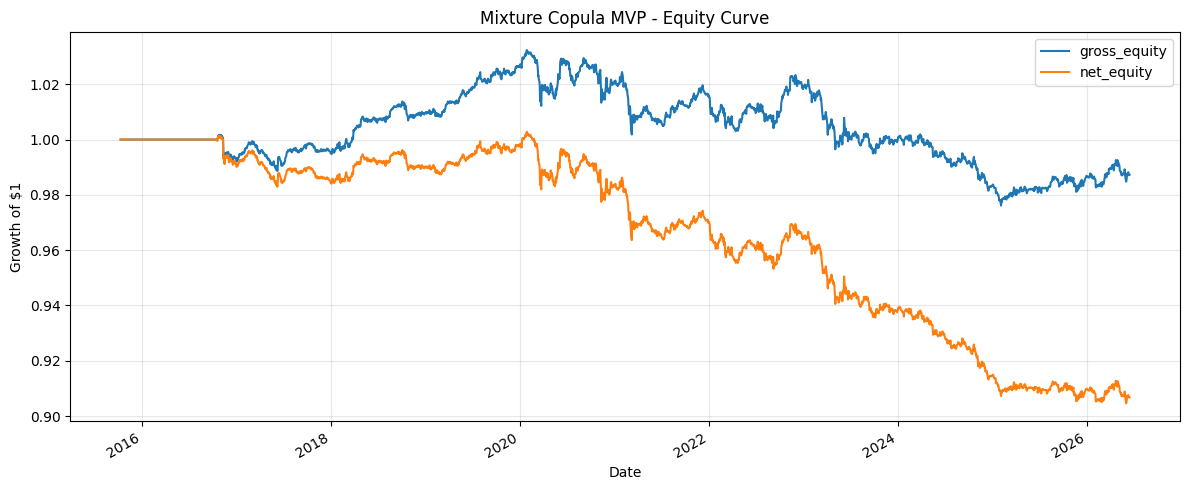

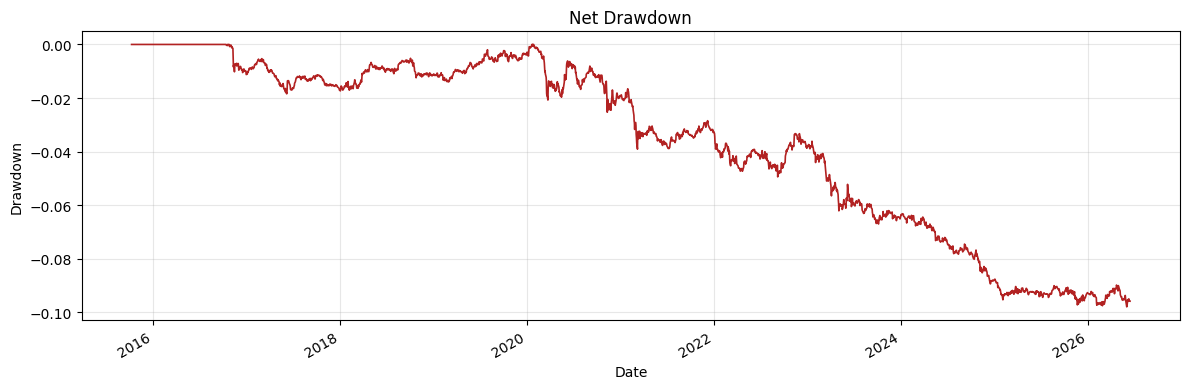

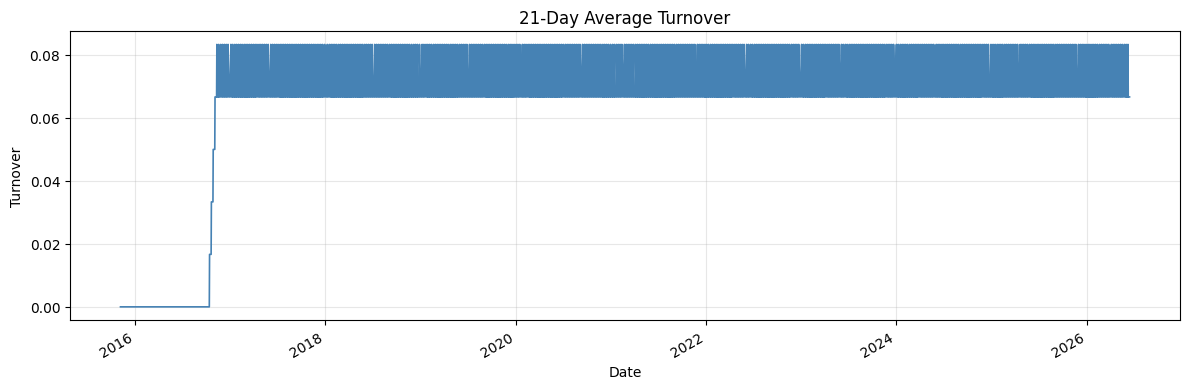

In [21]:
def plot_equity_curve(backtest: pd.DataFrame) -> None:
    fig, ax = plt.subplots(figsize=(12, 5))
    backtest[["gross_equity", "net_equity"]].plot(ax=ax, linewidth=1.5)
    model_label = CONFIG.copula_model.replace("_", "-").title()
    ax.set_title(f"{model_label} Copula MVP - Equity Curve")
    ax.set_ylabel("Growth of $1")
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    fig.savefig(PLOTS_DIR / "equity_curve.png", dpi=150)
    plt.show()


def plot_drawdown(backtest: pd.DataFrame) -> None:
    net_equity = backtest["net_equity"]
    drawdown = net_equity / net_equity.cummax() - 1.0
    fig, ax = plt.subplots(figsize=(12, 4))
    drawdown.plot(ax=ax, color="firebrick", linewidth=1.2)
    ax.set_title("Net Drawdown")
    ax.set_ylabel("Drawdown")
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    fig.savefig(PLOTS_DIR / "drawdown.png", dpi=150)
    plt.show()


def plot_turnover(backtest: pd.DataFrame) -> None:
    fig, ax = plt.subplots(figsize=(12, 4))
    backtest["turnover"].rolling(21).mean().plot(ax=ax, color="steelblue", linewidth=1.2)
    ax.set_title("21-Day Average Turnover")
    ax.set_ylabel("Turnover")
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    fig.savefig(PLOTS_DIR / "turnover.png", dpi=150)
    plt.show()


plot_equity_curve(backtest)
plot_drawdown(backtest)
plot_turnover(backtest)

## Robustness starter

La griglia sotto e volutamente piccola. Serve per iniziare a capire se il segnale sopravvive a variazioni ragionevoli dei parametri.

Per un report serio, ampliare la griglia e non scegliere la configurazione guardando il test set.

In [22]:
def run_small_robustness_grid(
    returns: pd.DataFrame,
    candidate_pairs: pd.DataFrame,
    copula_models: list[str] = ["gaussian", "student_t", "clayton", "mixture"],
    windows: list[int] = [126, 252],
    entry_scores: list[float] = [0.30, 0.35, 0.40, 0.45],
    top_n_values: list[int] = [3, 5, 10],
    rebalance_values: list[int] = [5, 10],
    max_turnover_values: list[float | None] = [0.25, 0.35, 0.50],
    costs_bps: list[float] = [0.0, 5.0],
) -> pd.DataFrame:
    rows: list[dict[str, object]] = []
    signal_cache: dict[tuple[str, int], pd.DataFrame] = {}

    for model in copula_models:
        for window in windows:
            cache_key = (model, window)
            if cache_key not in signal_cache:
                signal_cache[cache_key] = rolling_copula_pair_signals(
                    returns=returns,
                    pairs=candidate_pairs,
                    window=window,
                    copula_model=model,
                    student_t_df=CONFIG.student_t_df,
                    mixture_weights=CONFIG.mixture_weights,
                    output_path=None,
                )
            signals_for_window = signal_cache[cache_key]

            for entry_score in entry_scores:
                for top_n in top_n_values:
                    for rebalance_every_n_days in rebalance_values:
                        for max_daily_turnover in max_turnover_values:
                            positions_grid = build_positions_from_pair_signals(
                                signals_for_window,
                                returns,
                                top_n,
                                entry_score,
                                rebalance_every_n_days=rebalance_every_n_days,
                                max_daily_turnover=max_daily_turnover,
                                output_path=None,
                            )
                            for cost_bps in costs_bps:
                                bt_grid = run_backtest(positions_grid, returns, cost_bps=cost_bps, output_path=None)
                                metrics = performance_stats(bt_grid.loc[CONFIG.validation_start:CONFIG.validation_end], returns.loc[CONFIG.validation_start:CONFIG.validation_end])
                                rows.append(
                                    {
                                        "copula_model": model,
                                        "window": window,
                                        "entry_score": entry_score,
                                        "top_n_pairs": top_n,
                                        "rebalance_every_n_days": rebalance_every_n_days,
                                        "max_daily_turnover": max_daily_turnover,
                                        "cost_bps": cost_bps,
                                        **metrics,
                                    }
                                )

    robustness = pd.DataFrame(rows)
    robustness.to_csv(RESULTS_DIR / "robustness_table.csv", index=False)
    return robustness


RUN_ROBUSTNESS = False

if RUN_ROBUSTNESS:
    robustness_table = run_small_robustness_grid(returns, candidate_pairs)
    display(robustness_table.sort_values("sharpe_ratio", ascending=False).head(10))

## Interpretazione research

Dopo l'esecuzione, leggere i risultati con questa sequenza:

1. Il segnale ha average IC positivo?
2. Il rank IC conferma il risultato o e fragile?
3. La performance netta resta sensata dopo i costi?
4. Il test set e coerente con validation, o il risultato e concentrato in train?
5. Turnover e drawdown sono compatibili con una strategia realisticamente tradabile?

Se Gaussian, Student-t, Clayton e mixture non mostrano stabilita out-of-sample, prima vanno controllati pair universe, horizon del segnale, costi, beta exposure e robustezza dei parametri.

Estensioni naturali:

- stima rolling dei gradi di liberta della Student-t copula;
- confronto con Gumbel e Frank copula;
- stima rolling dei pesi mixture via conditional likelihood;
- beta-neutral sizing;
- IC decay a 1, 5 e 10 giorni;
- sector-neutral pair selection.